In [18]:
import torch
import json
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt

### Problem setup

Undamped Duffing oscillator with cubic nonlinearity:
$$\ddot{x} + x + \varepsilon x^3 = 0, \quad x(0)=1,\; \dot{x}(0)=0.$$

Epsilon sweep using the pretrained `undamped_k12` PTL-PINN backbone.

In [ ]:
train_root = "/home/jovyan/PTL-PINNs/ptlpinns/models/train"

t_span = (0, 10)
N = 500
t_eval = np.linspace(t_span[0], t_span[1], N)

w_0 = 1
ic = [1, 0]
q = [(3, 1)]
p_max = 5
REFINE = 1000

epsilon_values = np.arange(0.05, 2.0, 0.05)
forcing_fn = forcing.zeroes_2D(numpy=True)

model_name = "undamped_k12"
zeta = 0.0

In [20]:
def run_epsilon_sweep(H_dict, training_log, zeta, epsilon_values):
    """Run LPM epsilon sweep for a single damping value."""
    results = {}

    for epsilon in epsilon_values:
        ode = equations.ode_oscillator_1D(
            w_0=w_0, zeta=zeta,
            forcing_1D=lambda t: np.zeros_like(t),
            q=q, epsilon=epsilon,
        )

        if epsilon == 0.0:
            x_exact = numerical.solve_ode_equation(
                ode, t_span, t_eval, ic,
            )[0, :]
            results[epsilon] = {
                "mode": "linear",
                "error": [0.0] * (p_max + 1),
                "t_eval_lpm": t_eval,
                "x_num": x_exact,
                "x_pinn": x_exact,
            }
            continue

        error, w_sol = LPM.compute_error_per_order_lpm(
            H_dict=H_dict,
            training_log=training_log,
            w_0=w_0,
            zeta=zeta,
            epsilon=epsilon,
            p_max=p_max,
            ic=ic,
            forcing_function=forcing_fn,
            q=q,
            ode=ode,
            t_eval=t_eval,
            t_span=t_span,
            N=N,
            refine=REFINE,
            rwtol=0.0,
            check_divergence=False,
        )

        w_series = LPM.calculate_w_series(
            w_sol[0], epsilon, rwtol=0.0, check_divergence=False,
        )
        w_final = w_series[-1]
        t_eval_lpm, _ = LPM.t_eval_lpm(t_eval, w_final)

        w_sol_traj = []
        NN_TL, _, _ = transfer.compute_perturbation_solution(
            w_0_list=[w_0], zeta_list=[zeta], beta_list=[epsilon],
            p_list=[p_max], ic_list=[ic], forcing_list=[forcing_fn],
            H_dict=H_dict, t_eval=t_eval, training_log=training_log,
            all_p=True, comp_time=False, solver="LPM",
            w_sol=w_sol_traj, power=q,
        )
        NN_TL = NN_TL.squeeze()  # type: ignore

        t_lpm_hi = np.linspace(
            t_eval_lpm[0], t_eval_lpm[-1], (N - 1) * REFINE + 1,
        )
        x_num = numerical.solve_ode_equation(
            ode, (t_lpm_hi[0], t_lpm_hi[-1]), t_lpm_hi, ic,
        )[0, :][::REFINE]

        results[epsilon] = {
            "mode": "lpm",
            "error": error,
            "w_sol": w_sol,
            "w_final": w_final,
            "t_eval_lpm": t_eval_lpm,
            "x_num": x_num,
            "x_pinn": NN_TL[:, 0],
        }

    return results

### Epsilon sweep

Load the undamped backbone, build $H$, and run the Lindstedt–Poincaré pipeline
up to $p_{\max}=5$. MAE is measured against a high-accuracy numerical reference
on the PTL-PINN grid.

In [ ]:
model_path = f"{train_root}/{model_name}"
pinn_model, training_log = model.load_model(
    model_path, f"model_{model_name}.pth",
)
H_dict = transfer.compute_H_dict(
    pinn_model, N=N, bias=True, t_span=t_span,
)

print(f"Running undamped sweep (model={model_name}) ...")
results = run_epsilon_sweep(
    H_dict, training_log, zeta, epsilon_values,
)
print(f"done — {len(results)} epsilon values")

### MAE @ $p = p_{\max}$ vs $\varepsilon^{p_{\max}}$ — normalised comparison

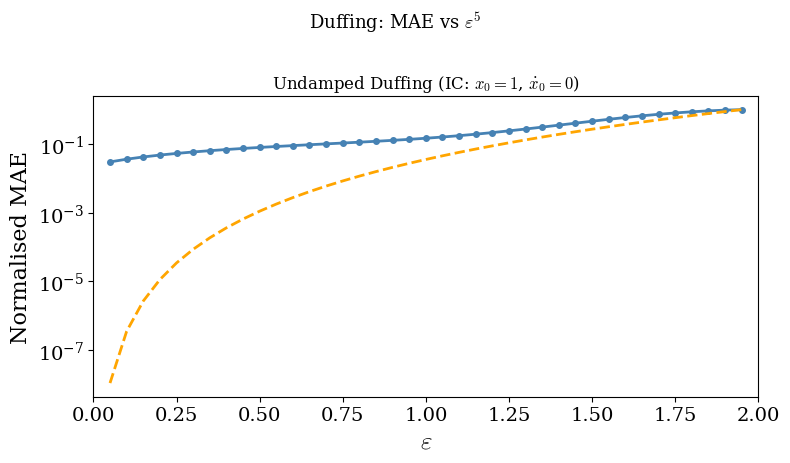

In [22]:
sweep_eps = np.array(sorted(results.keys()))
sweep_maes = np.array([results[eps]["error"][-1] for eps in sweep_eps])
sweep_eps_ref = sweep_eps ** p_max

mae_norm = sweep_maes / np.max(sweep_maes)
ref_norm = sweep_eps_ref / np.max(sweep_eps_ref)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(sweep_eps, mae_norm, "o-", linewidth=2, markersize=4,
        color="steelblue", label=rf"MAE @ $p={p_max}$")
ax.plot(sweep_eps, ref_norm, "--", linewidth=2,
        color="orange", label=rf"$\varepsilon^{{{p_max}}}$")

ax.set_title(
    rf"Undamped Duffing (IC: $x_0=1$, $\dot{{x}}_0=0$)",
    fontsize=12,
)
ax.set_yscale("log")
ax.set_xlim(0, 2.0)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.set_ylabel("Normalised MAE", fontsize=16)
#ax.grid(True, alpha=0.3, which="both")
#ax.legend(frameon=False, fontsize=10, loc="upper left")

fig.suptitle(
    rf"Duffing: MAE vs $\varepsilon^{{{p_max}}}$",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()